### code to apply yolo on video with opencv

In [2]:
pip install ultralytics

  Obtaining dependency information for ultralytics from https://files.pythonhosted.org/packages/5e/f4/df43a3e0341e41306e98eb31127171279d40864747fbc00d9ca966aba4ae/ultralytics-8.3.135-py3-none-any.whl.metadata
  Obtaining dependency information for matplotlib>=3.3.0 from https://files.pythonhosted.org/packages/a6/da/948a017c3ea13fd4a97afad5fdebe2f5bbc4d28c0654510ce6fd6b06b7bd/matplotlib-3.10.3-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for pillow>=7.1.2 from https://files.pythonhosted.org/packages/e2/72/25a8f40170dc262e86e90f37cb72cb3de5e307f75bf4b02535a61afcd519/pillow-11.2.1-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for pyyaml>=5.3.1 from https://files.pythonhosted.org/packages/ed/23/8da0bbe2ab9dcdd11f4f4557ccaf95c10b9811b13ecced089d43ce59c3c8/PyYAML-6.0.2-cp311-cp311-win_amd64.whl.metadata
  Using cached PyYAML-6.0.2-cp311-cp311-win_amd64.whl.metadata (2.1 kB)
  Obtaining dependency information for requests>=2.23.0 from https://f


[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import cv2
from ultralytics import YOLO

# Load the YOLOv5 model
model = YOLO("yolov8n.pt")  # Replace with your own model file path if needed

# Open the video file
video_file_path = r"person_video.mp4"
cap = cv2.VideoCapture(video_file_path)

if not cap.isOpened():
    print("Unable to open your video file!")
    exit()

while True:
    ret, frame = cap.read()

    if not ret:
        break

    # Perform inference on the frame (detection)
    results = model(frame)

    # `results` is a list; access the first result (typically index 0)
    result = results[0]  # This is the first result, which contains detections

    # Extract bounding boxes and labels
    boxes = result.boxes.xyxy  # (x1, y1, x2, y2)
    confidences = result.boxes.conf
    class_ids = result.boxes.cls  # Class IDs
    names = result.names  # Class names

    # Draw bounding boxes and labels on the frame
    for i in range(len(boxes)):
        x1, y1, x2, y2 = boxes[i].tolist()
        confidence = confidences[i].tolist()
        class_id = class_ids[i].tolist()
        label = f"{names[class_id]} {confidence:.2f}"

        # Draw rectangle (bounding box)
        color = (0, 255, 0)  # Green color for the box
        cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), color, 2)

        # Put the label (class name and confidence) on the frame
        cv2.putText(frame, label, (int(x1), int(y1) - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    # Display the frame with the detected bounding boxes
    cv2.imshow('YOLO Object Detection on Video', frame)

    # Wait for key press (press 'q' to exit the video)
    k = cv2.waitKey(10)  # 25 ms delay for video processing
    if k == ord('q'):
        break

# Release the video capture and close all windows
cap.release()
cv2.destroyAllWindows()



0: 384x640 35 persons, 2 birds, 55.1ms
Speed: 4.8ms preprocess, 55.1ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 35 persons, 3 birds, 39.6ms
Speed: 1.6ms preprocess, 39.6ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 35 persons, 3 birds, 39.9ms
Speed: 1.4ms preprocess, 39.9ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 36 persons, 2 birds, 54.9ms
Speed: 1.9ms preprocess, 54.9ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 36 persons, 2 birds, 42.2ms
Speed: 1.7ms preprocess, 42.2ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 35 persons, 3 birds, 37.6ms
Speed: 1.1ms preprocess, 37.6ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 35 persons, 2 birds, 37.7ms
Speed: 1.0ms preprocess, 37.7ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 36 persons, 2 birds, 38.5ms
S

### Apply detection on video source and saved the detected video into file with .mp4 formate

In [24]:
import cv2
from ultralytics import YOLO

# Load the YOLOv5 model
model = YOLO("yolov5s.pt")  # Replace with your own model file path if needed

# Open the video file
video_file_path = r"C:\Users\s86\Desktop\learning opencv\person_video.mp4"
cap = cv2.VideoCapture(video_file_path)

if not cap.isOpened():
    print("Unable to open your video file!")
    exit()

# Get video properties for output video (same resolution, same fps)
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

# Define codec and create VideoWriter object to save the output video as MP4
output_video_path = r"C:\Users\s86\Desktop\learning opencv\output_video.mp4"
fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Using 'mp4v' codec for MP4 format
out = cv2.VideoWriter(output_video_path, fourcc, fps, (frame_width, frame_height))

while True:
    ret, frame = cap.read()

    if not ret:
        break

    # Perform inference on the frame (detection)
    results = model(frame)

    # `results` is a list; access the first result (typically index 0)
    result = results[0]  # This is the first result, which contains detections

    # Extract bounding boxes and labels
    boxes = result.boxes.xyxy  # (x1, y1, x2, y2)
    confidences = result.boxes.conf
    class_ids = result.boxes.cls  # Class IDs
    names = result.names  # Class names

    # Draw bounding boxes and labels on the frame
    for i in range(len(boxes)):
        x1, y1, x2, y2 = boxes[i].tolist()
        confidence = confidences[i].item()
        class_id = class_ids[i].item()
        label = f"{names[class_id]} {confidence:.2f}"

        # Draw rectangle (bounding box)
        color = (0, 255, 0)  # Green color for the box
        cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), color, 2)

        # Put the label (class name and confidence) on the frame
        cv2.putText(frame, label, (int(x1), int(y1) - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    # Write the processed frame to the output video file
    out.write(frame)

    # Display the frame with the detected bounding boxes
    cv2.imshow('YOLO Object Detection on Video', frame)

    # Wait for key press (press 'q' to exit the video)
    k = cv2.waitKey(10)  # 10 ms delay for video processing
    if k == ord('q'):
        break

# Release the video capture and close all windows
cap.release()
out.release()  # Release the VideoWriter object
cv2.destroyAllWindows()


PRO TIP  Replace 'model=yolov5s.pt' with new 'model=yolov5su.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.


0: 384x640 24 persons, 128.0ms
Speed: 2.1ms preprocess, 128.0ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 26 persons, 73.0ms
Speed: 1.2ms preprocess, 73.0ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 27 persons, 70.3ms
Speed: 1.2ms preprocess, 70.3ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 28 persons, 69.8ms
Speed: 1.1ms preprocess, 69.8ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 26 persons, 1 bird, 68.6ms
Speed: 1.5ms preprocess, 68.6ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 27 persons, 1 bird, 75.0ms
Speed: 2.0ms preprocess, 75.0ms inference, 0.5ms postpr

### Count Bottles using YOLO

In [ ]:
result = results[0]
[v for k, v in result.names.items() if v[0].lower()=="b"]
# yolo have 'bottle' class 

['bicycle',
 'bus',
 'boat',
 'bench',
 'bird',
 'bear',
 'backpack',
 'baseball bat',
 'baseball glove',
 'bottle',
 'bowl',
 'banana',
 'broccoli',
 'bed',
 'book']

In [27]:
import cv2
from ultralytics import YOLO

video_file_path = r"C:\Users\s86\Desktop\learning opencv\battles.mp4"
model_name = "yolov5su"  # Use the fine-tuned YOLO model

# Load your fine-tuned YOLO model
model = YOLO(model_name)  # Replace with your own model

# Open the video file
cap = cv2.VideoCapture(video_file_path)

if not cap.isOpened():
    print("Unable to open the video file!")
    exit()

# Define a vertical line for counting (example at x = 400)
threshold_line_x = 400

# Initialize tracking data
counted_bottles = set()  # This will hold xmin values of bottles that have crossed
bottle_count = 0
frame_count = 0

while True:
    ret, frame = cap.read()

    if not ret:
        break

    # Perform inference on the frame (detection)
    results = model(frame)

    # Access results for the first frame
    result = results[0]

    # Extract bounding boxes and class names
    boxes = result.boxes.xyxy  # Bounding boxes (x1, y1, x2, y2)
    confidences = result.boxes.conf  # Confidence score for each detection
    class_ids = result.boxes.cls  # Class IDs for the detections
    names = result.names  # Class names (like 'person', 'bottle', etc.)

    # Prepare detections for tracking (only bottles)
    for i in range(len(boxes)):
        class_id = class_ids[i].item()
        if names[class_id] == "bottle":  # Check if the detected class is 'bottle'
            x1, y1, x2, y2 = boxes[i].tolist()

            # Check if the bottle's xmin (leftmost side of the bounding box) is within the threshold range
            if threshold_line_x < x1 <= threshold_line_x + 4 and x1 not in counted_bottles:
                # Bottle crosses the threshold range and has not been counted before
                counted_bottles.add(x1)  # Use xmin as a unique identifier
                bottle_count += 1  # Increment bottle count

    # Draw the threshold line on the frame
    cv2.line(frame, (threshold_line_x, 0), (threshold_line_x, frame.shape[0]), (0, 255, 0), 2)

    # Draw bounding boxes and labels for detected bottles
    for i in range(len(boxes)):
        class_id = class_ids[i].item()
        if names[class_id] == "bottle":
            x1, y1, x2, y2 = boxes[i].tolist()
            label = f"{names[class_id]} {confidences[i].item():.2f}"

            # Draw rectangle (bounding box)
            color = (0, 255, 0)  # Green color for the box
            cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), color, 2)

            # Put the label (class name and confidence) on the frame
            cv2.putText(frame, label, (int(x1), int(y1) - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    # Display the frame with the detected bounding boxes and threshold line
    cv2.putText(frame, f"Bottles Counted: {bottle_count}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.imshow('YOLO Object Detection - Bottle Counting with Threshold', frame)

    # Wait for key press (press 'q' to exit the video)
    k = cv2.waitKey(25)  # 10 ms delay for video processing
    if k == ord('q'):
        break

# Release video capture and close all windows
cap.release()
cv2.destroyAllWindows()



0: 640x384 (no detections), 63.9ms
Speed: 1.3ms preprocess, 63.9ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 train, 65.4ms
Speed: 1.2ms preprocess, 65.4ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 (no detections), 65.2ms
Speed: 1.2ms preprocess, 65.2ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 train, 66.8ms
Speed: 1.8ms preprocess, 66.8ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 train, 67.5ms
Speed: 2.1ms preprocess, 67.5ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 train, 67.6ms
Speed: 2.0ms preprocess, 67.6ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 train, 1 parking meter, 1 bottle, 67.5ms
Speed: 1.3ms preprocess, 67.5ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 train, 1 bottle, 65.7ms
Speed: 1.7ms preprocess, 65.7ms inference, 0

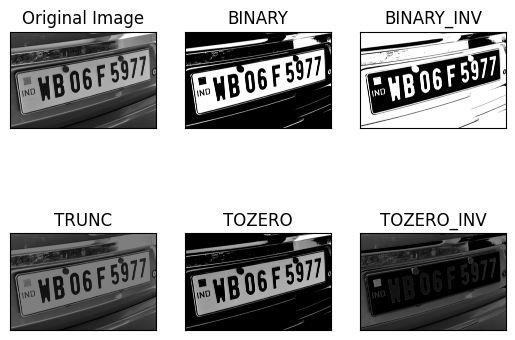

In [5]:
img = cv.imread(r'testimage\test2.jpg', cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"
ret,thresh1 = cv.threshold(img,127,255,cv.THRESH_BINARY)
ret,thresh2 = cv.threshold(img,127,255,cv.THRESH_BINARY_INV)
ret,thresh3 = cv.threshold(img,127,255,cv.THRESH_TRUNC)
ret,thresh4 = cv.threshold(img,127,255,cv.THRESH_TOZERO)
ret,thresh5 = cv.threshold(img,127,255,cv.THRESH_TOZERO_INV)
 
titles = ['Original Image','BINARY','BINARY_INV','TRUNC','TOZERO','TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]
 
for i in range(6):
    plt.subplot(2,3,i+1),plt.imshow(images[i],'gray',vmin=0,vmax=255)
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
 
plt.show()

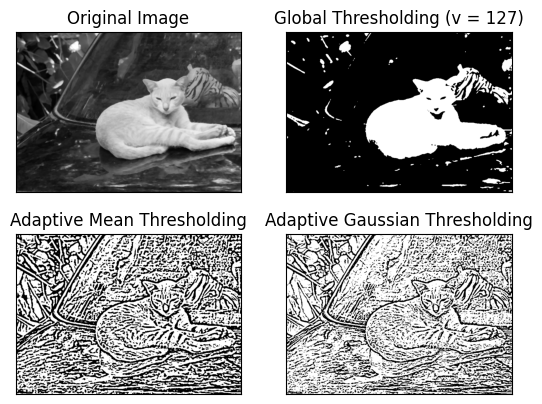

In [2]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
 
img = cv.imread(r'testimage\b.webp', cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"
img = cv.medianBlur(img,5)
 
ret,th1 = cv.threshold(img,127,255,cv.THRESH_BINARY)
th2 = cv.adaptiveThreshold(img,255,cv.ADAPTIVE_THRESH_MEAN_C,\
            cv.THRESH_BINARY,11,2)
th3 = cv.adaptiveThreshold(img,255,cv.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv.THRESH_BINARY,11,2)
 
titles = ['Original Image', 'Global Thresholding (v = 127)',
            'Adaptive Mean Thresholding', 'Adaptive Gaussian Thresholding']
images = [img, th1, th2, th3]
 
for i in range(4):
    plt.subplot(2,2,i+1),plt.imshow(images[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()

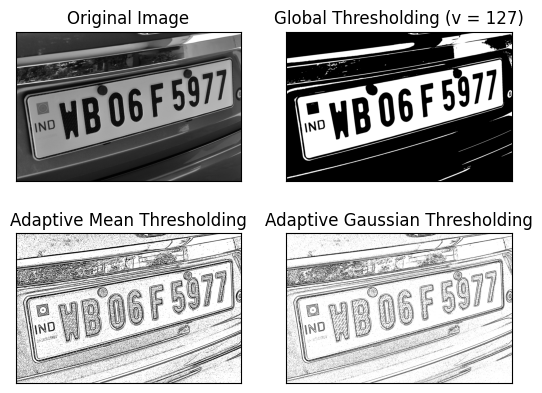

In [4]:
img = cv.imread(r'testimage\test2.jpg', cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"
img = cv.medianBlur(img,5)
 
ret,th1 = cv.threshold(img,127,255,cv.THRESH_BINARY)
th2 = cv.adaptiveThreshold(img,255,cv.ADAPTIVE_THRESH_MEAN_C,\
            cv.THRESH_BINARY,11,2)
th3 = cv.adaptiveThreshold(img,255,cv.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv.THRESH_BINARY,11,2)
 
titles = ['Original Image', 'Global Thresholding (v = 127)',
            'Adaptive Mean Thresholding', 'Adaptive Gaussian Thresholding']
images = [img, th1, th2, th3]
 
for i in range(4):
    plt.subplot(2,2,i+1),plt.imshow(images[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()

### Morphological operation 


In [30]:
import cv2 as cv
import numpy as np
 
img = cv.imread(r'testimage\jimage.jpg', cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"
kernel = np.ones((5,5),np.uint8)
erosion = cv.erode(img,kernel,iterations=1)

In [31]:
## Eroision 
cv.imshow("erosion result : ",erosion)
cv.waitKey(0) 
cv.destroyAllWindows()

In [33]:
# Dilation 
dilation = cv.dilate(img,kernel,iterations = 1)
cv.imshow("dilation result : ",dilation)

cv.waitKey(0) 
cv.destroyAllWindows()

### Image resizing

Original Image Shape: (1080, 1000, 3)
Resized Image Shape: (600, 600, 3)


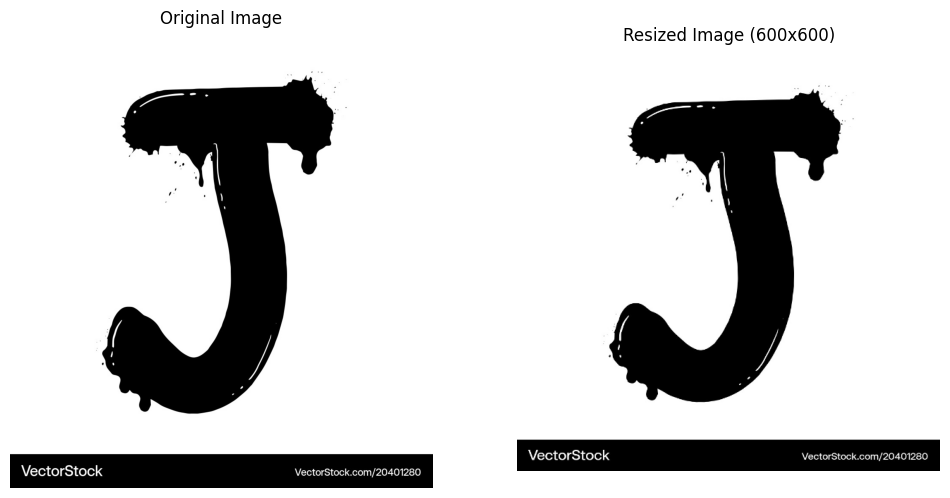

In [15]:
import cv2 as cv
import matplotlib.pyplot as plt

# Read the original image
img = cv.imread("testimage/jimage.jpg")

# Check if the image was successfully loaded
if img is None:
    print("Error: Image not found!")
    exit()

# Print the original image shape
print("Original Image Shape:", img.shape)

# Resize the image to 600x600
resized_img = cv.resize(img, (600, 600))

# Print the shape of the resized image
print("Resized Image Shape:", resized_img.shape)

# Convert BGR to RGB (OpenCV loads images in BGR, Matplotlib expects RGB)
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
resized_img_rgb = cv.cvtColor(resized_img, cv.COLOR_BGR2RGB)

# Plot the original and resized images side by side using Matplotlib
fig, ax = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns

# Display the original image
ax[0].imshow(img_rgb)
ax[0].set_title("Original Image")
ax[0].axis('off')  # Hide axes

# Display the resized image
ax[1].imshow(resized_img_rgb)
ax[1].set_title("Resized Image (600x600)")
ax[1].axis('off')  # Hide axes

# Show the plot
plt.show()


In [16]:
import numpy as np 

In [20]:
np.random.randint(1,20,(2,2,3))

array([[[13,  1, 10],
        [ 1, 16,  1]],

       [[10, 10, 10],
        [11, 10,  1]]])

In [22]:
arr = np.random.randint(0,255,(2,2,3))
arr 

array([[[ 83, 156,  21],
        [191, 171, 182]],

       [[135, 107,  32],
        [ 72,  98, 208]]])

In [30]:
arr.reshape(-1,3)

array([[ 83, 156,  21],
       [191, 171, 182],
       [135, 107,  32],
       [ 72,  98, 208]])

#### Bitwise_and function in opencv

In [ ]:
import cv2
import numpy as np

# Create two black images
image1 = np.zeros((300, 300), dtype=np.uint8)
image2 = np.zeros((300, 300), dtype=np.uint8)
image3 = np.zeros((300, 300), dtype=np.uint8)


# Draw white rectangles in both images
#                     xmin,ymin ,xmax,ymax   ,B , G , R 
cv2.rectangle(image1, (50, 50), (250, 250), (255,255,255), -1)
cv2.rectangle(image2, (100, 100), (200, 200), (0,0,0), -1)
cv2.circle(image3, (150,150), radius=40, color=(255,255,255), thickness=-1)  # -1 to fill the color


# Perform bitwise AND
result = cv2.bitwise_and(image1, image2)

# Display images
cv2.imshow("Image 1 WHITE RECT", image1)
cv2.imshow("Image 2 BLACK RECT", image2)
cv2.imshow("image 3",image3)
cv2.imshow("Bitwise AND Result WITH 0  --  1   -->  0  ", result)


# 1  --  1   -->  1
image1 = np.zeros((300, 300), dtype=np.uint8)   #
image2 = np.zeros((300, 300), dtype=np.uint8)
cv2.rectangle(image1, (50, 50), (250, 250), (255,255,255), -1)
cv2.rectangle(image2, (100, 100), (200, 200), (255,255,255), -1)
result2 = cv2.bitwise_and(image1,image2)
cv2.imshow("Bitwise AND Result WITH 1  --  1   -->  1  ", result2)


cv2.waitKey(0)
cv2.destroyAllWindows()


#### cv2.puttext()

In [ ]:
import numpy as np 
import cv2 
                                 # W , H     
image1 = np.random.randint(0,255,(640,640,3),dtype=np.uint8)
image1 = (image1 // 50) * 25

# putText(img,'text label',(cordinate start : width,height) , font style , font_scale(font-size),color,thickness)
cv2.putText(image1,"SAG Infotech",(0,30),cv2.FONT_HERSHEY_SIMPLEX,1,(0,255,0),thickness=2)
cv2.imshow("random_image  ",image1) 
cv2.waitKey(0)
cv2.destroyAllWindows()

#### change resolution of video

In [2]:
import cv2

# Open the input video
input_video_path = r'C:\Users\s86\Desktop\Learning Folder\OpenCV\battles.mp4'
cap = cv2.VideoCapture(input_video_path)

if not cap.isOpened():
    print("Error: Could not open video.")
    exit()

# Get the original video's width, height, and frames per second
original_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
original_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

# Set the new resolution
new_width = 480  # Set the desired width
new_height = 320  # Set the desired height

# Create a VideoWriter object to save the resized video
output_video_path = 'resolution_change_video.mp4'
fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Codec for .mp4 file
out = cv2.VideoWriter(output_video_path, fourcc, fps, (new_width, new_height))

while True:
    ret, frame = cap.read()
    if not ret:
        break  # End of video

    # Resize the frame to the new resolution
    resized_frame = cv2.resize(frame, (new_width, new_height))

    # Write the resized frame to the output video
    out.write(resized_frame)

# Release the video objects
cap.release()
out.release()

print(f"Video saved at {output_video_path}")


Video saved at resolution_change_video.mp4


#### cany edge detection

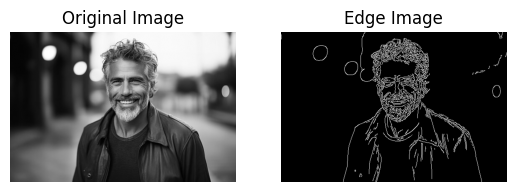

In [19]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
 
img = cv.imread('person1.jpg', cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"
edges = cv.Canny(img,100,150)  # 100 upper thresh , 150 lowe threshold
 
plt.subplot(121),plt.imshow(img,cmap = 'gray')
plt.title('Original Image'), plt.axis('off')
plt.subplot(122),plt.imshow(edges,cmap = 'gray')
plt.title('Edge Image'), plt.axis('off')
 
plt.show()